In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

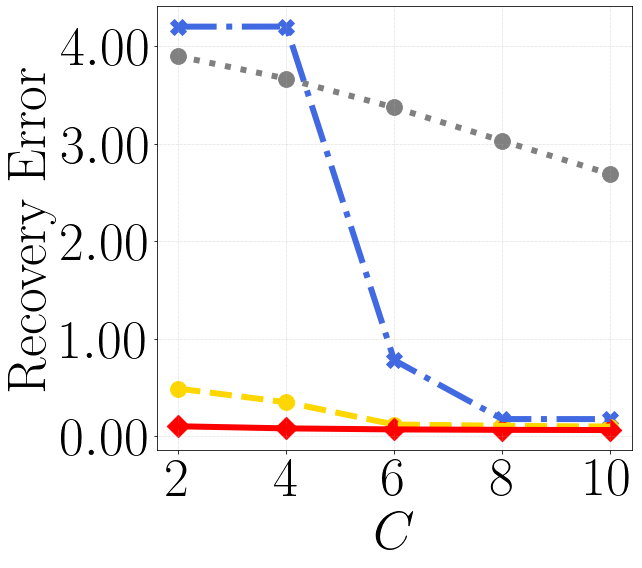

In [3]:
# observed entries
title = r'$\mathrm{Synthetic~(10^4~rows)}$'
#p = [0.002, 0.004, 0.006, 0.008, 0.01]
p = [2, 4, 6, 8, 10]
alt_GD = np.array([4.1998272, 4.2004914, 0.7799252, 0.1762353, 0.1761301])
softimpute_als = np.array([3.8955405, 3.6670523, 3.3708493, 3.0292181, 2.6883306])
nuclear_reg = np.array([0.4885208, 0.3486387, 0.1203968, 0.1076282, 0.0991828])
#iipw_1 = np.array([3.7779362, 3.1910096, 2.4069012, 1.6331401, 1.0081587])
iipw = np.array([0.1024208, 0.0807098, 0.0701371, 0.0658401, 0.0636271])

# alt_GD = np.array([4.7468433, 4.2344799, 4.1315956, 4.0593743, 3.6845982])
# softimpute_als = np.array([3.9461202, 3.8574507, 3.7324875, 3.5639453, 3.3840358])
# nuclear_reg = np.array([2.4381602, 0.8087983, 0.4039228, 0.0137906, 0.0116780])
# iipw = np.array([0.2950491, 0.0787201, 0.0227229, 0.0108300, 0.0089176])

f, ax = plt.subplots(figsize=(9,8))
plt.plot(p, alt_GD, lw=6, color='royalblue',ls="dashdot" )
plt.plot(p, softimpute_als, lw=6, color='grey', ls="dotted")
plt.plot(p, nuclear_reg, lw=6, color='gold', ls="dashed")
plt.plot(p, iipw, color='red',lw=6)

plt.scatter(p, alt_GD, s=250, color='royalblue', label=r"$\mathrm{Alternating~GD}$", marker="X")
plt.scatter(p, softimpute_als, s=250, color='grey', label=r"$\mathrm{SoftImpute~ALS}$", marker="o")
plt.scatter(p, nuclear_reg, s=250, color='gold', label=r"$\mathrm{Nuclear~Norm~Reg.}$")
plt.scatter(p, iipw, s=250, color='red', label=r"$\mathrm{Algorithm~1}$", marker="D")


#plt.legend(fontsize=34, loc='upper right', bbox_to_anchor=(1.02, 0.63))
# plt.title(title, fontsize=40)

plt.xlabel(r"$C$", fontsize=54)
plt.ylabel(r"$\mathrm{Recovery~Error}$", fontsize=54)


plt.xticks(fontsize=54)
#plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
#ax.xaxis.get_offset_text().set_fontsize(32)
plt.yticks([0,1,2,3,4],[r'$\mathrm{0.00}$', r'$\mathrm{1.00}$', r'$\mathrm{2.00}$', r'$\mathrm{3.00}$', r'$\mathrm{4.00}$'],fontsize=54)
plt.gca().xaxis.set_major_locator(MaxNLocator(5))
#plt.gca().yaxis.set_major_locator(MaxNLocator(4))
#plt.yscale("log", base=10)
#plt.ylim(,1.1)
#plt.legend(fontsize=26, loc='upper right', bbox_to_anchor=(0.8, 0.65))
plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"uniform_sampling_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

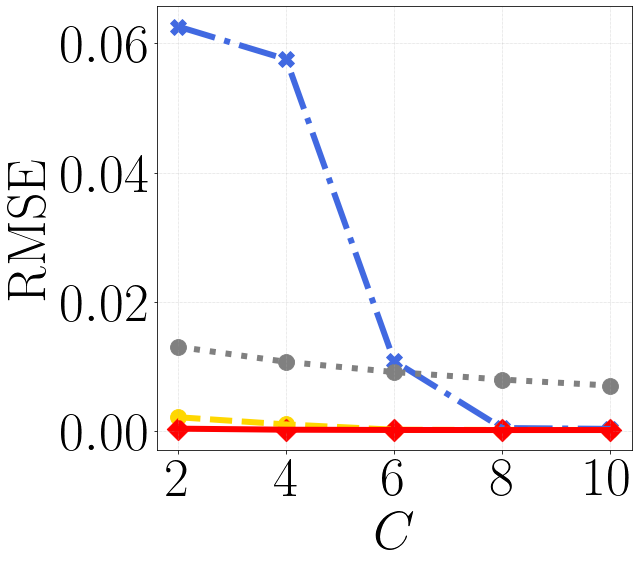

In [4]:
# observed entries
title = r'$\mathrm{Synthetic~(10^4~rows)}$'
#p = [0.002, 0.004, 0.006, 0.008, 0.01]
p = [2, 4, 6, 8, 10]
alt_GD_rmse = np.array([0.0626070, 0.0575438, 0.0108093, 0.0004410, 0.0003105])
softimpute_als_rmse = np.array([0.0130069, 0.0106883, 0.0091079, 0.0079454, 0.0070123])
nuclear_reg_rmse = np.array([0.0021108, 0.0009993, 0.0001764, 0.0001461, 0.0001330])
#iipw_1_rmse = np.array([0.0162836, 0.0093657, 0.0060119, 0.0038322, 0.0022689])
iipw_rmse = np.array([0.0003422, 0.0001787, 0.0001401, 0.0001265, 0.0001290])

# alt_GD_rmse = np.array([0.0637953, 0.0629831, 0.0613033, 0.0557394, 0.0407725])
# softimpute_als_rmse = np.array([0.0320334, 0.0205316, 0.0153736, 0.0140143, 0.0127871])
# nuclear_reg_rmse = np.array([0.0279646, 0.0129236, 0.0044353, 0.0002086, 0.0002023])
# iipw_rmse = np.array([0.0027650, 0.0009495, 0.0002783, 0.0002048, 0.0001978])

f, ax = plt.subplots(figsize=(9,8))
# print(ob2_rmse_mean)
# print(rmse_mean)
# plt.figure(figsize=(8,7))
# #plt.plot(X, original_err_mean, lw=6, label=r"$\tilde{M}^T\tilde{M}$")
# #plt.plot(X, T_prob_err_mean, lw=6, label=r"$T_{\mathrm{prob}}$")
# plt.plot(X, T_freq_rmse_mean, lw=6)
# #plt.plot(X, SVD_T_rmse_mean, lw=6, label=r"$\mathrm{SVD}$")
# plt.plot(X, ob2_rmse_mean, lw=6)
# #plt.plot(X, X_original_err_mean, lw=6, label=r"$X_{\tilde{M}^T\tilde{M}}$")

# plt.plot(X, rmse_mean, lw=6, color='limegreen')

# plt.scatter(X, T_freq_rmse_mean, s=200, label=r"$\mathcal{T}_{\hat{p}}$")
# plt.scatter(X, ob2_rmse_mean, s=200, label=r"$\|\cdot\|_\star~~\mathrm{reg.}$")

# plt.scatter(X, rmse_mean, s=200, color='limegreen', label=r"$X_k$")

plt.plot(p, alt_GD_rmse, lw=6, color='royalblue',ls="dashdot")
plt.plot(p, softimpute_als_rmse, lw=6, color='grey', ls="dotted")
plt.plot(p, nuclear_reg_rmse, lw=6, color='gold', ls="dashed")
plt.plot(p, iipw_rmse, color='red', lw=6)

plt.scatter(p, alt_GD_rmse, s=250, color='royalblue', label=r"$\mathrm{Alternating~GD}$", marker="X")
plt.scatter(p, softimpute_als_rmse, s=250, color='grey', label=r"$\mathrm{SoftImpute~ALS}$", marker="o")
plt.scatter(p, nuclear_reg_rmse, s=250, color='gold', label=r"$\mathrm{Nuclear~Norm~Reg.}$")
plt.scatter(p, iipw_rmse, s=250, color='red', label=r"$\mathrm{Algorithm~2}$", marker="D")




#plt.legend(fontsize=34, loc='upper right', bbox_to_anchor=(1.02, 1))
# plt.title(title, fontsize=40)

plt.xlabel(r"$C$", fontsize=54)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=54)

plt.xticks(fontsize=54)
#plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
#ax.xaxis.get_offset_text().set_fontsize(32)
plt.yticks(np.arange(0.02, 0.061, 0.02),fontsize=54)
plt.gca().xaxis.set_major_locator(MaxNLocator(5))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
#plt.yscale("log", base=10)
#plt.ylim(,1.1)

plt.grid(lw=0.5, ls=":")
#plt.legend(fontsize=26, loc='upper right')
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"uniform_sampling_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

/var/folders/j2/0zz11rkn3z7dlcnhcy6cjnbw0000gn/T/ipykernel_9154/3464609296.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


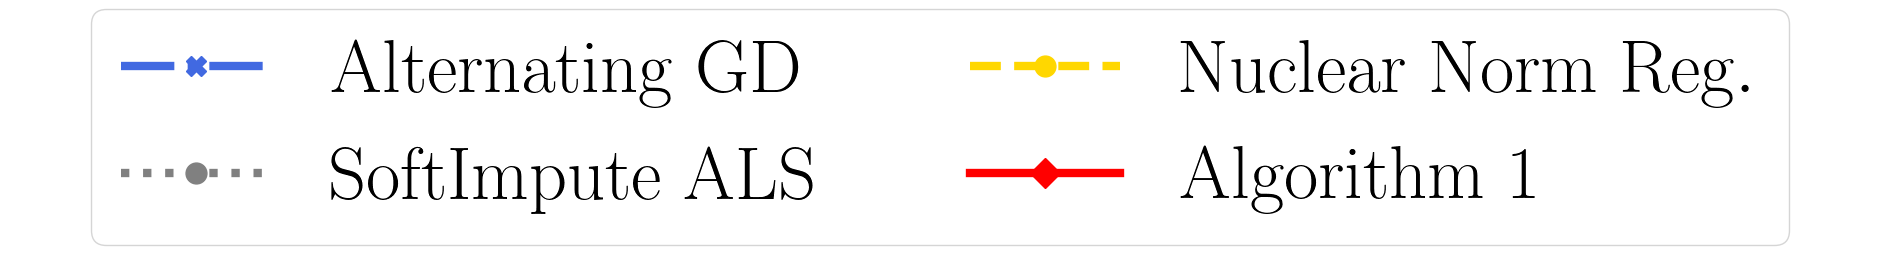

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import json

mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed
from matplotlib.lines import Line2D

# Create a figure and remove axes
fig, ax = plt.subplots(figsize=(24, 0.5))
fig.patch.set_visible(False)
ax.axis('off')

# Define dummy legend handles
legend_elements = [
    Line2D([0], [0], color='royalblue', lw=6, ls='dashdot', marker='X', markersize=15, label=r"$\mathrm{Alternating~GD}$"),
    Line2D([0], [0], color='grey', lw=6, ls='dotted', marker='o', markersize=15, label=r"$\mathrm{SoftImpute~ALS}$"),
    Line2D([0], [0], color='gold', lw=6, ls='dashed', marker='o', markersize=15, label=r"$\mathrm{Nuclear~Norm~Reg.}$"),
    Line2D([0], [0], color='red', lw=6, marker='D', markersize=15, label=r"$\mathrm{Algorithm~1}$")
]
# Create the legend
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,       # remove legend box border
    fontsize=54,
    ncol=2              # or more columns if needed
)

# Adjust layout and save
plt.tight_layout()
plt.savefig("legend_alg1.pdf", bbox_inches='tight', dpi=300)
plt.show()

/var/folders/j2/0zz11rkn3z7dlcnhcy6cjnbw0000gn/T/ipykernel_9154/66535979.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


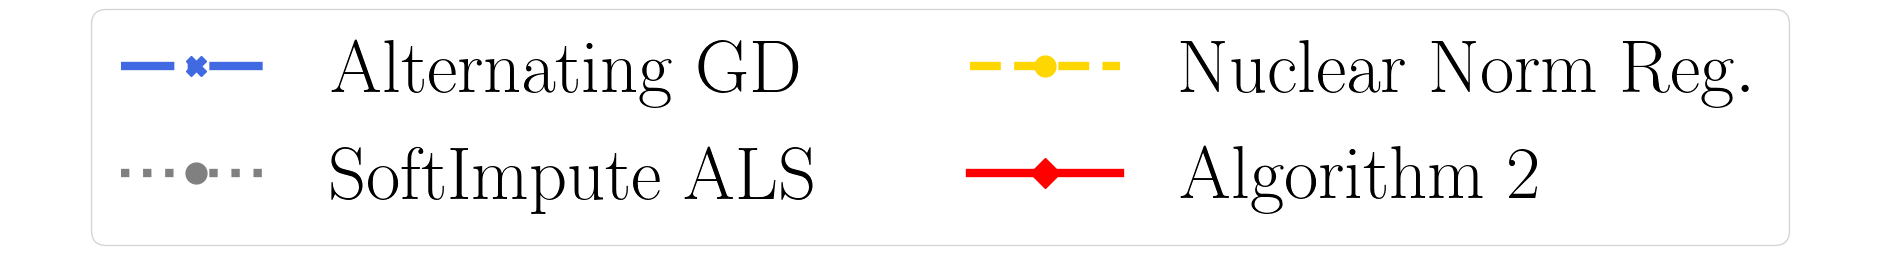

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import json

mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed
from matplotlib.lines import Line2D

# Create a figure and remove axes
fig, ax = plt.subplots(figsize=(24, 0.5))
fig.patch.set_visible(False)
ax.axis('off')

# Define dummy legend handles
legend_elements = [
    Line2D([0], [0], color='royalblue', lw=6, ls='dashdot', marker='X', markersize=15, label=r"$\mathrm{Alternating~GD}$"),
    Line2D([0], [0], color='grey', lw=6, ls='dotted', marker='o', markersize=15, label=r"$\mathrm{SoftImpute~ALS}$"),
    Line2D([0], [0], color='gold', lw=6, ls='dashed', marker='o', markersize=15, label=r"$\mathrm{Nuclear~Norm~Reg.}$"),
    Line2D([0], [0], color='red', lw=6, marker='D', markersize=15, label=r"$\mathrm{Algorithm~2}$")
]
# Create the legend
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,       # remove legend box border
    fontsize=54,
    ncol=2              # or more columns if needed
)

# Adjust layout and save
plt.tight_layout()
plt.savefig("legend_alg2.pdf", bbox_inches='tight', dpi=300)
plt.show()